# Material Classification from Multipath Profiles (No Angle/Power/Distance Features)

This notebook is a variant of `material_classifier_4.ipynb`, kept as close as possible to the original -- same file-count requirement (`expected_profile_rows == 48`, so files with missing rows are still dropped), same dual aux + peak-structured PyTorch `Dataset`, same MLP model shape, same training loop, same grouped K-fold check at the end.

**The one change: `v_angle`, `v_Power_Tx`, `distance_Rx`, and `distance_Tx` are removed from `AUX_FEATURE_NAMES`.** These four fields are constant across every row of a given file (they're per-file scalars, not per-row measurements), and with only ~54 usable files total across 4 materials, they can function more like a file identifier than a physical measurement -- if the experiment didn't test every material at every angle/power/distance combination, a model can shortcut by memorizing "this file's angle+power -> this material" on the training files, which inflates training accuracy without generalizing to new files. That's the leading explanation for the large train/test accuracy gap and the unstable, sign-flipping feature-importance results seen when exploring this data with a Random Forest.

`K_dB`, `PDP_RMS`, `P_sig_dBm_mean`, `P_sig_dBm_range`, and both peak-structured feature groups (`peak_val_IF`, `peak_loc_IF`) are all kept exactly as in the original notebook -- only the four suspected file-identity features are dropped.

## Package Requirements

In [20]:
# Uncomment only if you are missing packages.
#
#%pip install numpy scipy matplotlib torch

# 1. Imports and Configuration

The imports below include standard Python libraries, numerical tools, MATLAB loading tools, plotting tools, and PyTorch.

In [21]:
from pathlib import Path
from typing import Any, Dict, List, Tuple
import random
import re

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.12.1+cpu
CUDA available: False


In [22]:
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# 2. Locate the MATLAB Data

In [23]:
DATA_DIR = Path("Processed_Data_Points (missing rows)/combined/")

mat_files = sorted(DATA_DIR.glob("*.mat"))

print("Data directory:", DATA_DIR.resolve())
print("Number of .mat files found:", len(mat_files))

for path in mat_files[:5]:
    print(" ", path.name)

if len(mat_files) == 0:
    print("\nNo .mat files were found. Make sure your files are in projects/p3/data/*.mat")

Data directory: C:\Users\WINGS\Documents\Ashley\WINGS-2026\Processed_Data_Points (missing rows)\combined
Number of .mat files found: 80
  data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_125.mat
  data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_176.mat
  data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_250.mat
  data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_354.mat
  data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_500.mat


# 4. Helper Functions for MATLAB Arrays

MATLAB arrays do not always come into Python with the exact shape we expect.

The helper below converts a MATLAB variable into a clean 2D NumPy array:

```text
rows    = examples
columns = multipath samples
```

If the data is a 1D vector, we treat it as one example.

In [24]:
def numeric_2d(value: Any) -> np.ndarray:
    """
    Convert a MATLAB numeric profile-like variable to a 2D NumPy array.

    Output shape:
        (number_of_examples, number_of_samples)
    """
    arr = np.asarray(value)

    if arr.dtype == object:
        rows = []
        for item in arr.ravel():
            item_arr = np.asarray(item).squeeze().ravel()
            if item_arr.size > 0:
                rows.append(item_arr)

        if len(rows) == 0:
            return np.empty((0, 0), dtype=np.float32)

        max_len = max(len(row) for row in rows)
        out = np.full((len(rows), max_len), np.nan, dtype=np.float32)

        for i, row in enumerate(rows):
            out[i, : len(row)] = np.asarray(row, dtype=np.float32)

        return out

    arr = np.squeeze(arr)

    if arr.ndim == 0:
        return arr.reshape(1, 1).astype(np.float32)

    if arr.ndim == 1:
        return arr.reshape(1, -1).astype(np.float32)

    if arr.ndim == 2:
        # Heuristic:
        # If one dimension is very long and the other is small, the long dimension is probably samples.
        # We want shape: (examples, samples).
        if arr.shape[0] > 1000 and arr.shape[1] < 1000:
            arr = arr.T
        return arr.astype(np.float32)

    return arr.reshape(arr.shape[0], -1).astype(np.float32)

# 5. Parse Material Labels from Filenames

In [25]:
MATERIALS = ["wood", "drywall", "glass", "metal"]

FILENAME_RE = re.compile(
    r"""
    ^data
    _BW_(?P<bw>\d+(?:\.\d+)?)GHz
    _RF_(?P<rf>\d+(?:\.\d+)?)GHz
    (?P<material>[A-Za-z0-9]+)
    _Angle(?P<angle>\d+(?:\.\d+)?)
    _Power_(?P<power>-?\d+(?:\.\d+)?)
    \.mat$
    """,
    re.VERBOSE,
)

def parse_filename(path: Path) -> Dict[str, Any]:
    """Parse useful metadata from a MATLAB filename."""
    match = FILENAME_RE.match(path.name)

    if match is not None:
        return {
            "filename": path.name,
            "material": match.group("material").lower(),
            "angle_deg": float(match.group("angle")),
            "power": float(match.group("power")),
            "bandwidth_ghz": float(match.group("bw")),
            "rf_ghz": float(match.group("rf")),
        }

    lower_name = path.name.lower()
    material = "unknown"
    for candidate in MATERIALS:
        if candidate in lower_name:
            material = candidate
            break

    return {
        "filename": path.name,
        "material": material,
        "angle_deg": np.nan,
        "power": np.nan,
        "bandwidth_ghz": np.nan,
        "rf_ghz": np.nan,
    }

for path in mat_files[:5]:
    print(parse_filename(path))

{'filename': 'data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_125.mat', 'material': 'drywall', 'angle_deg': 25.0, 'power': 125.0, 'bandwidth_ghz': 4.0, 'rf_ghz': 300.0}
{'filename': 'data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_176.mat', 'material': 'drywall', 'angle_deg': 25.0, 'power': 176.0, 'bandwidth_ghz': 4.0, 'rf_ghz': 300.0}
{'filename': 'data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_250.mat', 'material': 'drywall', 'angle_deg': 25.0, 'power': 250.0, 'bandwidth_ghz': 4.0, 'rf_ghz': 300.0}
{'filename': 'data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_354.mat', 'material': 'drywall', 'angle_deg': 25.0, 'power': 354.0, 'bandwidth_ghz': 4.0, 'rf_ghz': 300.0}
{'filename': 'data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_500.mat', 'material': 'drywall', 'angle_deg': 25.0, 'power': 500.0, 'bandwidth_ghz': 4.0, 'rf_ghz': 300.0}


# 7. Build a PyTorch Dataset

A PyTorch `Dataset` defines how to access examples.

For this project, each example is:

```text
auxiliary feature tensor, peak-structured feature tensor, material label
```

The auxiliary feature tensor holds extra per-example metadata pulled straight from the `.mat` file. `v_angle`, `v_Power_Tx`, `distance_Rx`, and `distance_Tx` are **excluded** here -- see the notebook intro for why. `K_dB` and `PDP_RMS` are already one value per profile row and are used directly. `P_sig_dBm` carries *multiple* values per row and is reduced to summary statistics first, since a neural net input needs a fixed-size vector, not a ragged one:

- `P_sig_dBm` is `(48, 16)` -- 16 power readings per row -> reduced to `P_sig_dBm_mean`
  and `P_sig_dBm_range` (how strong the signal is, and how much it varies).
- `peak_val_IF` / `peak_loc_IF` are `(rows, n_peaks)`, NaN-padded because different rows
  can have a different number of detected multipath peaks -> reduced to
  `peak_val_IF_count`, `peak_val_IF_max`, `peak_val_IF_range`, and `peak_loc_IF_range`
  (how many distinct reflections were resolved, how strong the strongest one was, and how
  spread out the peaks are in strength and arrival time).

The full aux list lives in `AUX_FEATURE_NAMES` below. The aux tensor will have shape:

```text
[number_of_aux_features]
```

Alongside the aux tensor, a separate peak-structured feature tensor keeps each detected peak's (value, location) pair intact -- see `PEAK_STRUCT_FEATURE_NAMES` below. The model uses both the aux and peak-structured tensors as input; the raw multipath profile itself is only used to determine how many rows a file has and to validate row-count alignment, not as a model input.

The label will be an integer:

```text
0, 1, 2, or 3
```

**Important data quality note:** `K_dB` and `PDP_RMS` are stored as one value per row, and in a clean file there are 48 rows (matching 48 profile rows). Some files are missing rows in the multipath profile (e.g. 44 rows instead of 48), and there is no way to know which rows are missing -- so, same as `material_classifier_4.ipynb`, those files are skipped entirely rather than guessing at an alignment.

In [26]:
AUX_FEATURE_NAMES = [
    "K_dB",
    "PDP_RMS",
    # P_sig_dBm is (48, 16) -- 16 values per profile row, not one -- so it's reduced to
    # summary statistics per row rather than used directly. See row_array_stats_from_mat.
    "P_sig_dBm_mean",
    "P_sig_dBm_range",
    # v_angle, v_Power_Tx, distance_Rx, distance_Tx removed here: these are constant per
    # *file* (not per row), and with only ~54 usable files they can behave more like a
    # file ID than a physical measurement -- the leading suspect for the overfitting /
    # unstable feature-importance behavior seen when exploring this data with a Random
    # Forest. See the intro cell for the full reasoning.
    # peak_val_IF / peak_loc_IF summary stats (count/max/range) used to live here too, but
    # now live exclusively in PEAK_STRUCT_FEATURE_NAMES below, alongside the full
    # peak-structured (value, location) features -- see that block for why.
]

# A *separate*, peak-only feature set for testing the hypothesis that most of the useful
# signal lives in the resolved multipath peaks, not the noise floor in between them. Unlike
# the summary stats above (count/max/range), this keeps each peak's own (value, location)
# pair together, sorted by strength, so a model can see actual peak *structure* rather than
# just aggregate statistics about the peaks. Used to build dataset.peak_struct, a second,
# independent feature matrix alongside dataset.aux (see MultipathMaterialDataset below) --
# it does not change the existing AUX_FEATURE_NAMES / dataset.aux pipeline at all.
N_TOP_PEAKS = 8  # TODO: try 3-8. Limited by how many peaks the detector typically resolves.

PEAK_STRUCT_FEATURE_NAMES = (
    ["peak_val_IF_count"]
    + [f"peak_val_top{i + 1}" for i in range(N_TOP_PEAKS)]
    + [f"peak_loc_top{i + 1}" for i in range(N_TOP_PEAKS)]
)

EXPECTED_PROFILE_ROWS = 48
# Some .mat files are missing rows in the multipath profile (e.g. 44 rows instead of 48).
# The row-level variables (K_dB, PDP_RMS, Total_distance) are always the full 48 long, so
# if a file is short on profile rows we have no way of knowing which rows are missing and
# therefore can't safely line up profile row i with K_dB[i] / PDP_RMS[i] / Total_distance[i].
# We skip those files entirely rather than guess at an alignment.


def scalar_from_mat(mat: Dict[str, Any], key: str) -> float:
    """Pull a single per-file scalar out of a loaded .mat dict.

    Returns NaN for missing keys, conversion errors, AND non-finite values (inf/-inf).
    RF measurements can produce inf when a ratio (e.g. K-factor) divides by ~0, and an
    unguarded inf will silently turn into NaN loss once it reaches the model (inf - inf
    during normalization, or inf * weight during the forward pass).
    """
    if key not in mat:
        return float("nan")
    try:
        value = float(np.asarray(mat[key]).squeeze())
    except Exception:
        return float("nan")
    return value if np.isfinite(value) else float("nan")


def row_value_from_mat(mat: Dict[str, Any], key: str, row_idx: int) -> float:
    """
    Pull a per-row value (e.g. K_dB, PDP_RMS, shape (1, 48)) for a given profile row. Once
    files are filtered to EXPECTED_PROFILE_ROWS, the index should always be in range, but
    the bounds check is kept as a safety net. Non-finite values (inf/-inf) are also
    converted to NaN, same reasoning as scalar_from_mat above.
    """
    if key not in mat:
        return float("nan")
    arr = np.asarray(mat[key]).squeeze().ravel()
    if row_idx < arr.size:
        try:
            value = float(arr[row_idx])
        except Exception:
            return float("nan")
        return value if np.isfinite(value) else float("nan")
    return float("nan")


def row_array_stats_from_mat(mat: Dict[str, Any], key: str, row_idx: int) -> Dict[str, float]:
    """
    Pull a per-row *array* (multiple values per row) and reduce it to scalar summary
    statistics for one row. Used for fields like:

      - P_sig_dBm    shape (48, 16): 16 signal-power readings per profile row.
      - peak_val_IF  shape (rows, n_peaks): strength of each detected multipath peak.
      - peak_loc_IF  shape (rows, n_peaks): location/delay of each detected multipath peak.

    peak_val_IF / peak_loc_IF arrive from MATLAB as *cell* arrays (dtype=object, one cell
    per row, each cell holding its own ragged vector of peaks) rather than a plain
    rectangular array like P_sig_dBm. We route everything through numeric_2d(), the same
    helper used for the profile itself, which unpacks that object/cell layout into a clean
    NaN-padded 2D array regardless of which raw layout the field started in. Non-finite
    values (the NaN padding, plus any inf/-inf) are dropped before computing stats.
    Returns all-NaN if the key is missing, the row index is out of range, or the row has
    no finite values (e.g. no peaks were detected for that row).
    """
    nan_stats = {
        "count": float("nan"),
        "mean": float("nan"),
        "max": float("nan"),
        "min": float("nan"),
        "range": float("nan"),
    }

    if key not in mat:
        return dict(nan_stats)

    arr = numeric_2d(mat[key])

    if arr.size == 0 or row_idx >= arr.shape[0]:
        return dict(nan_stats)

    row = np.asarray(arr[row_idx], dtype=np.float64).ravel()
    row = row[np.isfinite(row)]

    if row.size == 0:
        return dict(nan_stats)

    row_max = float(np.max(row))
    row_min = float(np.min(row))

    return {
        "count": float(row.size),
        "mean": float(np.mean(row)),
        "max": row_max,
        "min": row_min,
        "range": row_max - row_min,
    }


def top_k_peaks_from_mat(
    mat: Dict[str, Any],
    val_key: str,
    loc_key: str,
    row_idx: int,
    k: int = N_TOP_PEAKS,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Extract up to k of the strongest detected multipath peaks for one row, keeping each
    peak's value paired with its own location (rather than summarizing values and locations
    separately, which would lose which location goes with which value).

    Returns two length-k arrays (vals, locs), sorted descending by peak strength (val).
    If a row has fewer than k real peaks, the remaining slots are NaN, to be imputed later
    with the column mean -- same convention as every other aux feature in this dataset.
    Both arrays are all-NaN if the key is missing, the row index is out of range, or the
    row has no finite, paired (value, location) peaks.
    """
    nan_out = np.full(k, np.nan, dtype=np.float64)

    if val_key not in mat or loc_key not in mat:
        return nan_out.copy(), nan_out.copy()

    val_arr = numeric_2d(mat[val_key])
    loc_arr = numeric_2d(mat[loc_key])

    if row_idx >= val_arr.shape[0] or row_idx >= loc_arr.shape[0]:
        return nan_out.copy(), nan_out.copy()

    vals_row = np.asarray(val_arr[row_idx], dtype=np.float64)
    locs_row = np.asarray(loc_arr[row_idx], dtype=np.float64)

    # Peaks are paired by position (peak i's value and peak i's location share an index).
    # Keep only positions where both sides are finite, so padding on either array can't
    # produce a fake (value, location) pair.
    n = min(vals_row.size, locs_row.size)
    vals_row = vals_row[:n]
    locs_row = locs_row[:n]
    finite_mask = np.isfinite(vals_row) & np.isfinite(locs_row)
    vals_row = vals_row[finite_mask]
    locs_row = locs_row[finite_mask]

    if vals_row.size == 0:
        return nan_out.copy(), nan_out.copy()

    order = np.argsort(vals_row)[::-1]  # strongest peak first
    vals_sorted = vals_row[order]
    locs_sorted = locs_row[order]

    out_vals = nan_out.copy()
    out_locs = nan_out.copy()
    take = min(k, vals_sorted.size)
    out_vals[:take] = vals_sorted[:take]
    out_locs[:take] = locs_sorted[:take]

    return out_vals, out_locs


class MultipathMaterialDataset(Dataset):
    """PyTorch Dataset for material classification using aux + peak-structured multipath features."""

    def __init__(
        self,
        root: Path,
        mp_key: str = "Multipath_Profile_X_corr_IF",
        materials: List[str] = None,
        aux_feature_names: List[str] = None,
        expected_profile_rows: int = EXPECTED_PROFILE_ROWS,
        verbose: bool = True,
    ):
        self.root = Path(root)
        self.mp_key = mp_key
        self.materials = materials if materials is not None else ["wood", "drywall", "glass", "metal"]
        self.material_to_label = {name: i for i, name in enumerate(self.materials)}
        self.label_to_material = {i: name for name, i in self.material_to_label.items()}
        self.aux_feature_names = aux_feature_names if aux_feature_names is not None else list(AUX_FEATURE_NAMES)
        self.expected_profile_rows = expected_profile_rows

        self.labels: List[int] = []
        self.meta: List[Dict[str, Any]] = []
        self.raw_aux: List[List[float]] = []
        self.raw_peak_struct: List[List[float]] = []
        self.peak_struct_feature_names: List[str] = list(PEAK_STRUCT_FEATURE_NAMES)
        self.skipped_row_mismatch: List[str] = []

        files = sorted(self.root.glob("*.mat"))

        if len(files) == 0:
            raise RuntimeError(f"No .mat files found in {self.root}")

        for path in files:
            info = parse_filename(path)
            material = info["material"]

            if material not in self.material_to_label:
                if verbose:
                    print(f"[skip] {path.name}: unknown material {material!r}")
                continue

            try:
                mat = loadmat(path, squeeze_me=False, struct_as_record=False)
            except Exception as exc:
                if verbose:
                    print(f"[skip] {path.name}: could not load file: {exc}")
                continue

            if self.mp_key not in mat:
                if verbose:
                    print(f"[skip] {path.name}: missing variable {self.mp_key}")
                continue

            profiles_2d = numeric_2d(mat[self.mp_key])

            if profiles_2d.size == 0:
                if verbose:
                    print(f"[skip] {path.name}: empty multipath variable")
                continue

            if profiles_2d.shape[0] != self.expected_profile_rows:
                if verbose:
                    print(
                        f"[skip] {path.name}: expected {self.expected_profile_rows} profile rows, "
                        f"found {profiles_2d.shape[0]} (row-level features would not line up safely)"
                    )
                self.skipped_row_mismatch.append(path.name)
                continue

            # peak_val_IF / peak_loc_IF are per-acquisition (like the profile itself), not
            # always the fixed EXPECTED_PROFILE_ROWS length like K_dB/PDP_RMS are. If a
            # file's peak arrays don't have one row per profile row, we can't safely say
            # peak row i corresponds to profile row i -- so we treat peak-derived features
            # as missing (NaN, later filled with the column mean) for that file only,
            # rather than risk a silent misalignment or skipping the whole file.
            peak_val_arr = np.asarray(mat["peak_val_IF"]) if "peak_val_IF" in mat else None
            peak_loc_arr = np.asarray(mat["peak_loc_IF"]) if "peak_loc_IF" in mat else None

            peak_rows_aligned = True
            for arr, arr_name in [(peak_val_arr, "peak_val_IF"), (peak_loc_arr, "peak_loc_IF")]:
                if arr is not None and arr.shape[0] != profiles_2d.shape[0]:
                    peak_rows_aligned = False
                    if verbose:
                        print(
                            f"[warn] {path.name}: {arr_name} has {arr.shape[0]} rows but the "
                            f"profile has {profiles_2d.shape[0]} rows; peak-derived aux features "
                            "for this file will be treated as missing rather than risk misalignment."
                        )

            for row_idx in range(profiles_2d.shape[0]):
                self.labels.append(self.material_to_label[material])

                # Per-row stats. Safe to index directly now that rows are guaranteed
                # to match EXPECTED_PROFILE_ROWS, but row_value_from_mat keeps a
                # bounds check as a safety net.
                k_db = row_value_from_mat(mat, "K_dB", row_idx)
                pdp_rms = row_value_from_mat(mat, "PDP_RMS", row_idx)

                p_sig_stats = row_array_stats_from_mat(mat, "P_sig_dBm", row_idx)

                if peak_rows_aligned:
                    peak_val_stats = row_array_stats_from_mat(mat, "peak_val_IF", row_idx)
                    peak_loc_stats = row_array_stats_from_mat(mat, "peak_loc_IF", row_idx)
                else:
                    peak_val_stats = {"count": float("nan"), "max": float("nan"), "range": float("nan")}
                    peak_loc_stats = {"range": float("nan")}

                aux_lookup = {
                    "K_dB": k_db,
                    "PDP_RMS": pdp_rms,
                    "P_sig_dBm_mean": p_sig_stats["mean"],
                    "P_sig_dBm_range": p_sig_stats["range"],
                    "peak_val_IF_count": peak_val_stats["count"],
                    "peak_val_IF_max": peak_val_stats["max"],
                    "peak_val_IF_range": peak_val_stats["range"],
                    "peak_loc_IF_range": peak_loc_stats["range"],
                }
                self.raw_aux.append([aux_lookup[name] for name in self.aux_feature_names])

                # Peak-structured features: same alignment guard as the peak summary stats
                # above (peak_rows_aligned), since these also come from peak_val_IF /
                # peak_loc_IF. This builds a SEPARATE feature matrix (dataset.peak_struct)
                # from dataset.aux -- it doesn't affect the existing aux pipeline at all.
                if peak_rows_aligned:
                    peak_vals_topk, peak_locs_topk = top_k_peaks_from_mat(
                        mat, "peak_val_IF", "peak_loc_IF", row_idx, k=N_TOP_PEAKS
                    )
                else:
                    peak_vals_topk = np.full(N_TOP_PEAKS, np.nan)
                    peak_locs_topk = np.full(N_TOP_PEAKS, np.nan)

                peak_struct_lookup = {"peak_val_IF_count": peak_val_stats["count"]}
                for i in range(N_TOP_PEAKS):
                    peak_struct_lookup[f"peak_val_top{i + 1}"] = peak_vals_topk[i]
                    peak_struct_lookup[f"peak_loc_top{i + 1}"] = peak_locs_topk[i]

                self.raw_peak_struct.append(
                    [peak_struct_lookup[name] for name in self.peak_struct_feature_names]
                )

                row_meta = dict(info)
                row_meta["row"] = row_idx

                self.meta.append(row_meta)

        if len(self.labels) == 0:
            raise RuntimeError("No valid multipath profiles were loaded.")

        self.y = np.asarray(self.labels, dtype=np.int64)

        # Build and normalize the aux feature matrix.
        raw_aux = np.asarray(self.raw_aux, dtype=np.float32)  # shape: (N, F)

        # scalar_from_mat / row_value_from_mat / row_array_stats_from_mat already convert
        # non-finite values to NaN, so a plain isnan check here covers missing keys, bad
        # conversions, AND inf/-inf.
        nonfinite_counts = np.isnan(raw_aux).sum(axis=0)

        # Fill NaNs per-column with that column's mean (computed ignoring NaNs).
        col_means = np.nanmean(raw_aux, axis=0)
        col_means = np.where(np.isnan(col_means), 0.0, col_means)
        nan_mask = np.isnan(raw_aux)
        for col in range(raw_aux.shape[1]):
            raw_aux[nan_mask[:, col], col] = col_means[col]

        # Z-score each aux feature column. Stats are saved on the dataset object so
        # they can be reused (and stored alongside the trained model) at inference time.
        self.aux_mean = raw_aux.mean(axis=0)
        self.aux_std = raw_aux.std(axis=0)
        safe_std = np.where(self.aux_std > 0, self.aux_std, 1.0)
        self.aux = ((raw_aux - self.aux_mean) / safe_std).astype(np.float32)

        # Build and normalize the peak-structured feature matrix the same way as aux above
        # (NaN -> column mean, then z-score). This is a separate matrix from self.aux; the
        # model concatenates aux and peak_struct as its input (see MultipathPeakMLP below).
        raw_peak_struct = np.asarray(self.raw_peak_struct, dtype=np.float32)  # shape: (N, P)

        peak_struct_nonfinite_counts = np.isnan(raw_peak_struct).sum(axis=0)

        peak_struct_col_means = np.nanmean(raw_peak_struct, axis=0)
        peak_struct_col_means = np.where(np.isnan(peak_struct_col_means), 0.0, peak_struct_col_means)
        peak_struct_nan_mask = np.isnan(raw_peak_struct)
        for col in range(raw_peak_struct.shape[1]):
            raw_peak_struct[peak_struct_nan_mask[:, col], col] = peak_struct_col_means[col]

        self.peak_struct_mean = raw_peak_struct.mean(axis=0)
        self.peak_struct_std = raw_peak_struct.std(axis=0)
        safe_peak_struct_std = np.where(self.peak_struct_std > 0, self.peak_struct_std, 1.0)
        self.peak_struct = (
            (raw_peak_struct - self.peak_struct_mean) / safe_peak_struct_std
        ).astype(np.float32)

        if verbose:
            print(f"Loaded {len(self)} examples from {len(files)} .mat files")
            print(f"Skipped {len(self.skipped_row_mismatch)} files due to row-count mismatch")
            if self.skipped_row_mismatch:
                preview = self.skipped_row_mismatch[:10]
                print("  e.g.:", preview)
            print("Aux feature shape:", self.aux.shape, "names:", self.aux_feature_names)
            print(
                "Non-finite aux values replaced with column mean (per feature):",
                dict(zip(self.aux_feature_names, nonfinite_counts.tolist())),
            )
            print("Aux value range after z-scoring (min, max):", self.aux.min(axis=0), self.aux.max(axis=0))
            print("Peak-structured feature shape:", self.peak_struct.shape, "names:", self.peak_struct_feature_names)
            print(
                "Non-finite peak-structured values replaced with column mean (per feature):",
                dict(zip(self.peak_struct_feature_names, peak_struct_nonfinite_counts.tolist())),
            )
            print("Materials:", self.material_to_label)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx: int):
        aux = torch.from_numpy(self.aux[idx])
        peak_struct = torch.from_numpy(self.peak_struct[idx])
        label = torch.tensor(self.y[idx], dtype=torch.long)

        return {
            "aux": aux,
            "peak_struct": peak_struct,
            "label": label,
            "material": self.label_to_material[int(self.y[idx])],
            "meta": self.meta[idx],
        }

## Create the Dataset

This is the first place where you may need to adjust the settings.

Important settings:

- `mp_key`: MATLAB variable name for the multipath profile (used to validate row counts)
- `aux_feature_names`: which per-example metadata fields to use alongside the peak structure
- `expected_profile_rows`: files with a different row count are skipped (see note above)

In [27]:
MP_KEY = "Multipath_Profile_X_corr_IF"  # update only if your MATLAB variable has a different name.

dataset = MultipathMaterialDataset(
    root=DATA_DIR,
    mp_key=MP_KEY,
    verbose=True,
)

print("Dataset length:", len(dataset))
print("One sample keys:", dataset[0].keys())
print("One aux shape:", dataset[0]["aux"].shape)
print("One aux vector:", dataset[0]["aux"])
print("One label:", dataset[0]["label"])
print("One material:", dataset[0]["material"])

[skip] data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_125.mat: expected 48 profile rows, found 44 (row-level features would not line up safely)
[skip] data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_176.mat: expected 48 profile rows, found 45 (row-level features would not line up safely)
[skip] data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_250.mat: expected 48 profile rows, found 45 (row-level features would not line up safely)
[skip] data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_354.mat: expected 48 profile rows, found 45 (row-level features would not line up safely)
[skip] data_BW_4GHz_RF_300GHzDrywall_Angle25_Power_500.mat: expected 48 profile rows, found 45 (row-level features would not line up safely)
[skip] data_BW_4GHz_RF_300GHzDrywall_Angle5_Power_176.mat: expected 48 profile rows, found 47 (row-level features would not line up safely)
[skip] data_BW_4GHz_RF_300GHzGlass_Angle25_Power_125.mat: expected 48 profile rows, found 45 (row-level features would not line up safely)
[skip] data_BW_4

# 10. Train / Validation / Test Split

We will split the dataset into:

- training set
- validation set
- test set

**Important: we split by *file*, not by row.** Each `.mat` file contributes ~44-48 rows
that all come from the *same* physical measurement (same material, angle, and power) -
they are repeated/adjacent measurements, not independent samples of "what does this
material look like." If we stratified over individual rows, rows from one file could end
up in both train and test, and the model could learn file-specific quirks (calibration,
noise floor, etc.) instead of material-general features. That would inflate our accuracy
numbers without the model actually generalizing better.

Instead, we first decide which *files* go to train/val/test (stratified by material so
each split has a reasonable class balance), and then every row belonging to a file follows
that file's split assignment.

In [28]:
def stratified_split_files(
    meta: List[Dict[str, Any]],
    labels: np.ndarray,
    train_ratio: float = 0.70,
    val_ratio: float = 0.15,
    seed: int = 42,
) -> Tuple[List[int], List[int], List[int]]:
    """
    Create train/validation/test indices while preserving class balance, splitting whole
    *files* at a time so rows from the same file never end up on both sides of a split.

    Rows within a file are highly correlated (same material/angle/power measurement), so
    splitting at the row level leaks information between train and test. Splitting at the
    file level keeps each split's files disjoint, which is the right unit for measuring how
    well the model generalizes to a new physical setup.
    """
    rng = random.Random(seed)
    labels = np.asarray(labels)

    # Map each filename -> its material label, and each filename -> the row indices
    # (into the dataset) that belong to it.
    file_to_label: Dict[str, int] = {}
    file_to_row_indices: Dict[str, List[int]] = {}

    for idx, row_meta in enumerate(meta):
        fname = row_meta["filename"]
        file_to_label.setdefault(fname, int(labels[idx]))
        file_to_row_indices.setdefault(fname, []).append(idx)

    # Group filenames by material label so we can stratify at the file level.
    files_by_label: Dict[int, List[str]] = {}
    for fname, label in file_to_label.items():
        files_by_label.setdefault(label, []).append(fname)

    train_files: List[str] = []
    val_files: List[str] = []
    test_files: List[str] = []

    for label, files in files_by_label.items():
        files = list(files)
        rng.shuffle(files)

        n = len(files)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)

        train_files.extend(files[:n_train])
        val_files.extend(files[n_train:n_train + n_val])
        test_files.extend(files[n_train + n_val:])

    def files_to_indices(file_list: List[str]) -> List[int]:
        indices: List[int] = []
        for fname in file_list:
            indices.extend(file_to_row_indices[fname])
        return indices

    train_indices = files_to_indices(train_files)
    val_indices = files_to_indices(val_files)
    test_indices = files_to_indices(test_files)

    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    rng.shuffle(test_indices)

    print(f"Files -> train: {len(train_files)}, val: {len(val_files)}, test: {len(test_files)}")

    return train_indices, val_indices, test_indices

train_idx, val_idx, test_idx = stratified_split_files(dataset.meta, dataset.y, seed=SEED)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

print("Train examples:", len(train_dataset))
print("Validation examples:", len(val_dataset))
print("Test examples:", len(test_dataset))

Files -> train: 36, val: 7, test: 11
Train examples: 1728
Validation examples: 336
Test examples: 528


# 11. DataLoaders

A `DataLoader` creates batches.

For this project, a batch of aux features will have shape:

```text
[batch_size, number_of_aux_features]
```

and a batch of peak-structured features will have shape:

```text
[batch_size, number_of_peak_struct_features]
```

In [29]:
BATCH_SIZE = 32  # TODO: can try different values like 16, 32, or 64.

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))

print("Batch aux shape:", batch["aux"].shape)
print("Batch label shape:", batch["label"].shape)
print("First labels:", batch["label"][:10])
print("First materials:", batch["material"][:10])

Batch aux shape: torch.Size([32, 4])
Batch label shape: torch.Size([32])
First labels: tensor([0, 3, 1, 0, 2, 1, 2, 0, 0, 1])
First materials: ['wood', 'metal', 'drywall', 'wood', 'glass', 'drywall', 'glass', 'wood', 'wood', 'drywall']


# 12. Build a Peak-Structured MLP Model

The raw multipath profile has ~12,500 samples, but physically only a handful correspond to
real resolved reflections -- the rest is correlation noise floor around those peaks. With
only a few dozen independent measurement files, forcing a CNN to learn to ignore ~12,500
mostly-noise samples from scratch is a lot of freedom for very little data.

This model drops the raw profile entirely and classifies using only:

```text
aux          (K_dB, PDP_RMS, P_sig_dBm stats, peak summary stats -- 8 features)

peak_struct  (the top N_TOP_PEAKS detected multipath peaks, each kept as a paired
              (value, location) entry sorted by strength, plus the total peak count)

[aux, peak_struct] -> concat -> MLP -> classifier
```

`peak_struct` comes straight from the peak detector already in this pipeline
(`peak_val_IF` / `peak_loc_IF`), just kept in structured form (paired value + location per
peak) instead of raw. This is a much more compact, physically-motivated representation of
the same information a raw-profile CNN would otherwise have to rediscover on its own.

In [30]:
NUM_CLASSES = 4  # TODO: wood, drywall, glass, metal.
NUM_AUX_FEATURES = dataset.aux.shape[1]  # K_dB, PDP_RMS, P_sig_dBm stats, peak summary stats
NUM_PEAK_STRUCT_FEATURES = dataset.peak_struct.shape[1]  # peak count + top-N peak (value, location) pairs
IN_FEATURES = NUM_AUX_FEATURES + NUM_PEAK_STRUCT_FEATURES
HIDDEN_SIZE = 32  # TODO: try a larger value if this underfits, smaller if it overfits.

class MultipathPeakMLP(nn.Module):
    """
    Material classifier over aux + peak-structured features only -- no raw multipath
    profile input. The raw profile is mostly correlation noise floor around a handful of
    real, already-detected reflections; with only a few dozen independent measurement
    files, forcing a CNN to learn to ignore ~12,500 mostly-noise samples from scratch is a
    lot of freedom for very little data. This model instead uses the peaks directly: the
    top N_TOP_PEAKS detected peaks (value + location, paired and sorted by strength) plus
    the existing per-row aux features (K-factor, delay spread, signal power, peak summary
    stats).
    """

    def __init__(self, num_classes: int = 4, in_features: int = IN_FEATURES, hidden: int = HIDDEN_SIZE):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, aux, peak_struct):
        combined = torch.cat([aux, peak_struct], dim=1)
        return self.net(combined)

model = MultipathPeakMLP(
    num_classes=NUM_CLASSES,
    in_features=IN_FEATURES,
    hidden=HIDDEN_SIZE,
).to(device)

print(model)
print("Number of trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

MultipathPeakMLP(
  (net): Sequential(
    (0): Linear(in_features=21, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=4, bias=True)
  )
)
Number of trainable parameters: 1892


# 13. Loss Function and Optimizer

This is a classification problem, so we use `CrossEntropyLoss`.

The optimizer updates the model weights. We will use Adam because it is a good beginner default.

In [31]:
LEARNING_RATE = 1e-3  # TODO: try 1e-3 first.
EPOCHS = 10           # TODO: try 5 first, then 10 or 20.

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 14. Training and Evaluation Functions

These functions are very similar to the training loop you used in Project 1.

The model learns only during `train_one_epoch`. During `evaluate`, the model is tested without updating weights.

In [32]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for batch in loader:
        aux = batch["aux"].to(device)
        peak_struct = batch["peak_struct"].to(device)
        labels = batch["label"].to(device)

        logits = model(aux, peak_struct)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += batch_size

    avg_loss = total_loss / total_examples
    avg_accuracy = total_correct / total_examples

    return avg_loss, avg_accuracy

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for batch in loader:
        aux = batch["aux"].to(device)
        peak_struct = batch["peak_struct"].to(device)
        labels = batch["label"].to(device)

        logits = model(aux, peak_struct)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += batch_size

    avg_loss = total_loss / total_examples
    avg_accuracy = total_correct / total_examples

    return avg_loss, avg_accuracy

# 15. Train the Material Classifier

In [33]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {100 * train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {100 * val_acc:.2f}%"
    )

Epoch 01/10 | Train Loss: 1.3331 | Train Acc: 42.82% | Val Loss: 1.2474 | Val Acc: 50.30%
Epoch 02/10 | Train Loss: 1.0769 | Train Acc: 56.54% | Val Loss: 1.0560 | Val Acc: 50.89%
Epoch 03/10 | Train Loss: 0.9386 | Train Acc: 60.82% | Val Loss: 1.0059 | Val Acc: 54.76%
Epoch 04/10 | Train Loss: 0.8785 | Train Acc: 62.27% | Val Loss: 0.9635 | Val Acc: 58.33%
Epoch 05/10 | Train Loss: 0.8547 | Train Acc: 63.08% | Val Loss: 0.9479 | Val Acc: 58.33%
Epoch 06/10 | Train Loss: 0.8339 | Train Acc: 64.47% | Val Loss: 0.9744 | Val Acc: 56.55%
Epoch 07/10 | Train Loss: 0.8113 | Train Acc: 64.76% | Val Loss: 0.9703 | Val Acc: 56.55%
Epoch 08/10 | Train Loss: 0.8103 | Train Acc: 64.58% | Val Loss: 0.9442 | Val Acc: 57.74%
Epoch 09/10 | Train Loss: 0.7936 | Train Acc: 65.28% | Val Loss: 0.9725 | Val Acc: 57.44%
Epoch 10/10 | Train Loss: 0.7775 | Train Acc: 65.80% | Val Loss: 0.9557 | Val Acc: 58.63%


# 16. Plot Training Curves

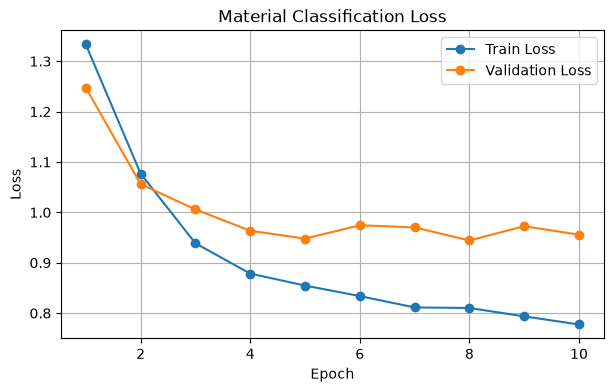

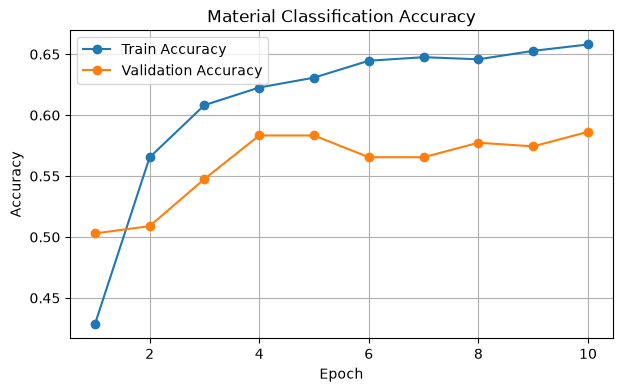

In [34]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Material Classification Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_accuracy"], marker="o", label="Train Accuracy")
plt.plot(epochs, history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Material Classification Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# 17. Test the Model

In [35]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {100 * test_acc:.2f}%")

Test Loss: 1.1415
Test Accuracy: 49.62%


# 18. Confusion Matrix

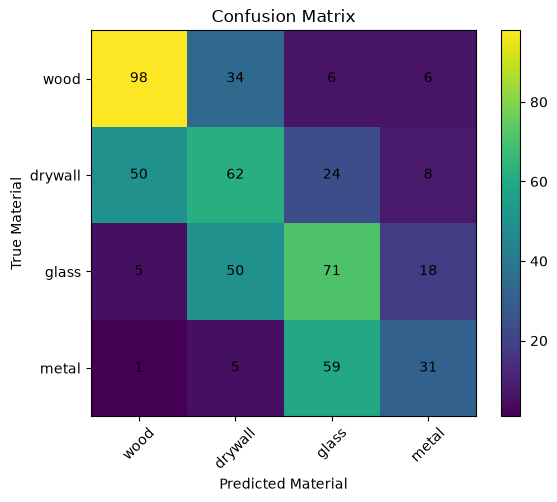

In [36]:
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()

    all_true = []
    all_pred = []

    for batch in loader:
        aux = batch["aux"].to(device)
        peak_struct = batch["peak_struct"].to(device)
        labels = batch["label"].to(device)

        logits = model(aux, peak_struct)
        preds = logits.argmax(dim=1)

        all_true.extend(labels.cpu().numpy().tolist())
        all_pred.extend(preds.cpu().numpy().tolist())

    return np.asarray(all_true), np.asarray(all_pred)

def make_confusion_matrix(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)

    for true_label, pred_label in zip(y_true, y_pred):
        cm[int(true_label), int(pred_label)] += 1

    return cm

y_true, y_pred = collect_predictions(model, test_loader, device)
cm = make_confusion_matrix(y_true, y_pred, num_classes=NUM_CLASSES)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Material")
plt.ylabel("True Material")
plt.xticks(range(NUM_CLASSES), dataset.materials, rotation=45)
plt.yticks(range(NUM_CLASSES), dataset.materials)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

# 21. Grouped K-Fold Cross-Validation (Robustness Check)

With the file-level split above, a single train/val/test split only holds out a handful of
files per class for testing (we have ~54-80 usable files total across 4 materials). That
means the single test accuracy above can swing a fair bit depending on which specific files
happened to land in the test set.

To get a more reliable estimate, we repeat training with **grouped K-fold cross-validation**:
we split the files (not rows) into `K` folds, stratified by material, and rotate which fold
is held out as the test set. Every row from a given file always stays in the same fold, so
no fold's test set contains rows from a file any other fold trained on - this preserves the
same "split by physical setup, not by row" principle as the main split above.

We report the mean and standard deviation of test accuracy across folds. This is slower
(it trains `K` models from scratch) but gives a much more trustworthy sense of how well the
model actually generalizes, and how much that estimate varies. Worth comparing this
notebook's mean/std directly against `material_classifier_4.ipynb`'s -- if dropping
`v_angle`/`v_Power_Tx`/`distance_Rx`/`distance_Tx` was really removing a file-identity
shortcut rather than useful signal, test accuracy here should hold up (or improve) while
the train/test gap should shrink.

In [37]:
def grouped_kfold_splits(
    meta: List[Dict[str, Any]],
    labels: np.ndarray,
    n_splits: int = 5,
    seed: int = 42,
):
    """
    Yield (train_indices, test_indices) pairs for grouped, stratified K-fold cross-validation,
    where a "group" is one source .mat file. Every row from a file is always assigned to the
    same fold, so a file used for testing in one fold is never partially seen during training
    in that same fold.

    Files are distributed round-robin across folds *within each material class*, so class
    balance across folds stays as even as the file counts allow.
    """
    rng = random.Random(seed)
    labels = np.asarray(labels)

    file_to_label: Dict[str, int] = {}
    file_to_row_indices: Dict[str, List[int]] = {}

    for idx, row_meta in enumerate(meta):
        fname = row_meta["filename"]
        file_to_label.setdefault(fname, int(labels[idx]))
        file_to_row_indices.setdefault(fname, []).append(idx)

    files_by_label: Dict[int, List[str]] = {}
    for fname, label in file_to_label.items():
        files_by_label.setdefault(label, []).append(fname)

    fold_files: List[List[str]] = [[] for _ in range(n_splits)]
    for label, files in files_by_label.items():
        files = list(files)
        rng.shuffle(files)
        for i, fname in enumerate(files):
            fold_files[i % n_splits].append(fname)

    for fold_idx in range(n_splits):
        test_files = set(fold_files[fold_idx])
        train_files = [f for f in file_to_label if f not in test_files]

        train_indices = [i for fname in train_files for i in file_to_row_indices[fname]]
        test_indices = [i for fname in test_files for i in file_to_row_indices[fname]]

        rng.shuffle(train_indices)
        rng.shuffle(test_indices)

        yield fold_idx, train_indices, test_indices, sorted(test_files)

In [38]:
N_FOLDS = 4  # TODO: try 4-6. Limited by how many files per class you have.

fold_test_accuracies = []

for fold_idx, fold_train_idx, fold_test_idx, fold_test_files in grouped_kfold_splits(
    dataset.meta, dataset.y, n_splits=N_FOLDS, seed=SEED
):
    set_seed(SEED + fold_idx)  # fresh, reproducible init per fold

    fold_model = MultipathPeakMLP(
        num_classes=NUM_CLASSES,
        in_features=IN_FEATURES,
        hidden=HIDDEN_SIZE,
    ).to(device)

    fold_criterion = nn.CrossEntropyLoss()
    fold_optimizer = torch.optim.Adam(fold_model.parameters(), lr=LEARNING_RATE)

    fold_train_loader = DataLoader(Subset(dataset, fold_train_idx), batch_size=BATCH_SIZE, shuffle=True)
    fold_test_loader = DataLoader(Subset(dataset, fold_test_idx), batch_size=BATCH_SIZE, shuffle=False)

    for epoch in range(EPOCHS):
        train_one_epoch(fold_model, fold_train_loader, fold_criterion, fold_optimizer, device)

    _, fold_test_acc = evaluate(fold_model, fold_test_loader, fold_criterion, device)
    fold_test_accuracies.append(fold_test_acc)

    print(
        f"Fold {fold_idx + 1}/{N_FOLDS} | "
        f"train rows: {len(fold_train_idx)} | "
        f"test rows: {len(fold_test_idx)} | "
        f"test files: {fold_test_files} | "
        f"test accuracy: {100 * fold_test_acc:.2f}%"
    )

fold_test_accuracies = np.asarray(fold_test_accuracies)
print()
print(
    f"Mean test accuracy across {N_FOLDS} folds: "
    f"{100 * fold_test_accuracies.mean():.2f}% "
    f"(+/- {100 * fold_test_accuracies.std():.2f}%)"
)

Fold 1/4 | train rows: 1872 | test rows: 720 | test files: ['data_BW_4GHz_RF_300GHzDrywall_Angle45_Power_176.mat', 'data_BW_4GHz_RF_300GHzDrywall_Angle5_Power_500.mat', 'data_BW_4GHz_RF_300GHzDrywall_Angle65_Power_125.mat', 'data_BW_4GHz_RF_300GHzDrywall_Angle65_Power_500.mat', 'data_BW_4GHz_RF_300GHzGlass_Angle45_Power_176.mat', 'data_BW_4GHz_RF_300GHzGlass_Angle45_Power_250.mat', 'data_BW_4GHz_RF_300GHzGlass_Angle45_Power_500.mat', 'data_BW_4GHz_RF_300GHzGlass_Angle65_Power_354.mat', 'data_BW_4GHz_RF_300GHzMetal_Angle45_Power_354.mat', 'data_BW_4GHz_RF_300GHzMetal_Angle45_Power_500.mat', 'data_BW_4GHz_RF_300GHzMetal_Angle65_Power_354.mat', 'data_BW_4GHz_RF_300GHzWood_Angle45_Power_500.mat', 'data_BW_4GHz_RF_300GHzWood_Angle5_Power_125.mat', 'data_BW_4GHz_RF_300GHzWood_Angle65_Power_125.mat', 'data_BW_4GHz_RF_300GHzWood_Angle65_Power_500.mat'] | test accuracy: 49.72%
Fold 2/4 | train rows: 1872 | test rows: 720 | test files: ['data_BW_4GHz_RF_300GHzDrywall_Angle45_Power_354.mat', 'dat